<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/FFT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

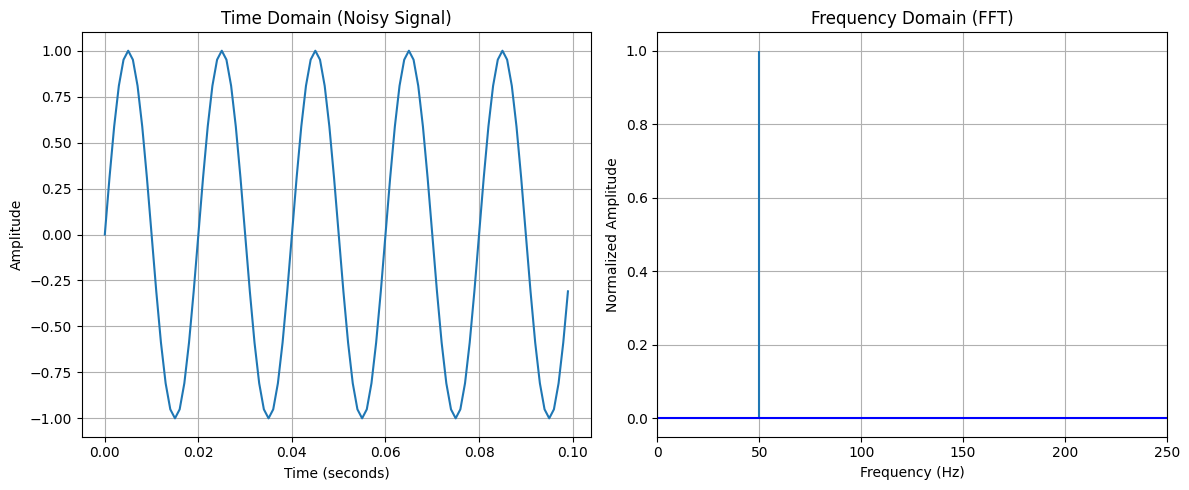

In [27]:
# @title Komputasi

import numpy as np
import matplotlib.pyplot as plt

# 1. Setup signal parameters
sample_rate = 1000  # Hz (Number of samples per second)
duration = 0.5     # Seconds
n_samples = int(sample_rate * duration)
time = np.linspace(0, duration, n_samples, endpoint=False)

# 2. Generate a mixed signal (50 Hz sine wave + 120 Hz sine wave + noise)
signal_50hz = np.sin(2 * np.pi * 50 * time)
signal_120hz = 0.5 * np.sin(2 * np.pi * 120 * time)
noise = np.random.normal(0, 0.5, n_samples)
mixed_signal = signal_50hz #+ signal_120hz + noise

# 3. Compute the FFT
# Calculate raw FFT values
fft_values = np.fft.fft(mixed_signal)
# Calculate corresponding frequency bins
frequencies = np.fft.fftfreq(n_samples, 1 / sample_rate)

# 4. Get one-sided spectrum (positive frequencies only)
half_samples = n_samples // 2
positive_frequencies = frequencies[:half_samples]
# Normalize amplitude
fft_amplitudes = np.abs(fft_values[:half_samples]) * 2 / n_samples

# 5. Plot the results
plt.figure(figsize=(12, 5))

# Plot Time Domain
plt.subplot(1, 2, 1)
plt.plot(time[:100], mixed_signal[:100])  # Plot first 100 samples for clarity
plt.title("Time Domain (Noisy Signal)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot Frequency Domain
plt.subplot(1, 2, 2)
plt.stem(positive_frequencies, fft_amplitudes, markerfmt=" ", basefmt="-b")
plt.title("Frequency Domain (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.xlim(0, 250)  # Zoom in on frequencies of interest
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
# @title Save to File (binary)
import numpy as np
from google.colab import files

# Define the filename for the text file
txt_filename = 'mixed_signal.txt'
sine_float_file = 'sine_float.txt'
sine_bin_file = 'sine_binary.txt'
num_bit = 16

# Save the mixed_signal array to a text file
#np.savetxt(txt_filename, mixed_signal)
#print(f"'mixed_signal' values saved to {txt_filename}")
np.savetxt(sine_float_file, signal_50hz)

# 1. Normalize and scale signal to 8-bit integer (0-255)
# This is necessary because raw floats don't have a simple 'binary' text representation
#sig_min, sig_max = mixed_signal.min(), mixed_signal.max()
#scaled_signal = ((mixed_signal - sig_min) / (sig_max - sig_min) * 255).astype(np.uint8)
scaled_sine = (signal_50hz * (2**(num_bit-1)-1)).astype(np.uint16)

# 2. Convert to binary strings and save
#binary_txt_filename = 'mixed_signal_binary.txt'
#with open(binary_txt_filename, 'w') as f:
#    for val in scaled_signal:
#        # format(val, '08b') converts integer to an 8-character binary string
#        f.write(format(val, '08b') + '\n')
with open(sine_bin_file, 'w') as f:
    for val in scaled_sine:
        f.write(format(val, '016b') + '\n')

#print(f"Saved binary strings to {binary_txt_filename}")

# 3. Optional: Download the file
#files.download(sine_bin_file)

In [ ]:
# @title Recovering data file
recovered_signal = []

# 1. Read binary strings from the file
with open(sine_bin_file, 'r') as f:
    for line in f:
        # Convert binary string back to integer
        val_int = int(line.strip(), 2)
        # Reverse the scaling (convert back to float)
        val_float = val_int / (2**15 - 1)
        recovered_signal.append(val_float)

# Convert list to numpy array for easier handling
recovered_signal = np.array(recovered_signal)

# 2. Display comparison
print(f"Original (first 5):  {signal_50hz[:20]}")
print(f"Recovered (first 5): {recovered_signal[:20]}")

# 3. Plot recovered signal to verify
plt.figure(figsize=(10, 4))
plt.plot(time[:100], recovered_signal[:100])
plt.title("Recovered Signal from Binary Text File")
plt.grid(True)
plt.show()